In [133]:
import atom
import matplotlib.pyplot as plt
import mrcfile
import pdbtools
import potential
import propagators
import torch
from tqdm import tqdm
from fft_tools import fftconvolve
import ice

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Plotting functions

In [2]:
def plot3d(vol):
    fig, axes = plt.subplots(1, 3, dpi=200, constrained_layout=True)
    for i, ax in enumerate(axes.ravel()):
        im = ax.imshow(vol.sum(i))
        ax.set(xticks=[], yticks=[], title=f"projection along axis {i}")
        fig.colorbar(im, ax=ax, location="bottom")
    plt.show()


def plot_slices(
    vol, start_idx=0, end_idx=None, axis=0, ylabel=None, vmin=None, vmax=None
):
    nslices = 5
    sh = vol.shape
    if end_idx is None:
        idx_length = sh[axis] - start_idx - 1
        end_idx = start_idx + idx_length
    else:
        idx_length = end_idx - start_idx
    idx_interval = idx_length // nslices
    indices = torch.linspace(start_idx, end_idx, nslices).type(torch.int)

    fig, axes = plt.subplots(1, 5, dpi=200, figsize=(8, 2.5), constrained_layout=True)
    for ax, i in zip(axes.ravel(), indices):
        ax.set(xticks=[], yticks=[])
        if axis == 0:
            im = ax.imshow(vol[i, :, :], vmin=vmin, vmax=vmax)
        elif axis == 1:
            im = ax.imshow(vol[:, i, :], vmin=vmin, vmax=vmax)
        elif axis == 2:
            im = ax.imshow(vol[:, :, i], vmin=vmin, vmax=vmax)
        ax.set_title(f"Slice {i}")
        fig.colorbar(im, ax=ax, location="bottom")

    if ylabel is not None:
        axes[0].set_ylabel(ylabel)
    plt.suptitle(f"Slices along axis {axis}")
    plt.show()

## Download PDB file

In [123]:
folder = "./pdb-data/"
filename = pdbtools.fetch_pdb_file("6e9d", output=folder)
filename

PDB file saved to: ./pdb-data/6e9d.cif


'./pdb-data/6e9d.cif'

## Extract atomic coordinates and recenter onto (0,0,0)

In [124]:
# extracts raw coordinates for each atom in (x,y,z) order from pdb file
atomic_numbers, coords = pdbtools.get_atoms_and_coordinates_from_pdb(filename)
atomic_numbers.shape, coords.shape

(torch.Size([489900]), torch.Size([489900, 3]))

In [125]:
# elements in particle
print(set(atom.atom_symbol(atomic_numbers)))

{'S', 'N', 'C', 'H', 'O'}


In [126]:
# recenters coordinates onto origin (0,0,0)
center = pdbtools.center_of_particle(coords)
centered_coords = coords - center.reshape(1, -1)

## Compute volumetric potential from PDB (3D, Snap, Low Res)

In [128]:
dx = 0.788
n = 512
super_sampling_factor = 4
vol_snapped_3d = potential.build_potential_volume_fftconvolve(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="snapped-3d",
    compute_high_res=False
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:20<00:00,  4.16s/it]


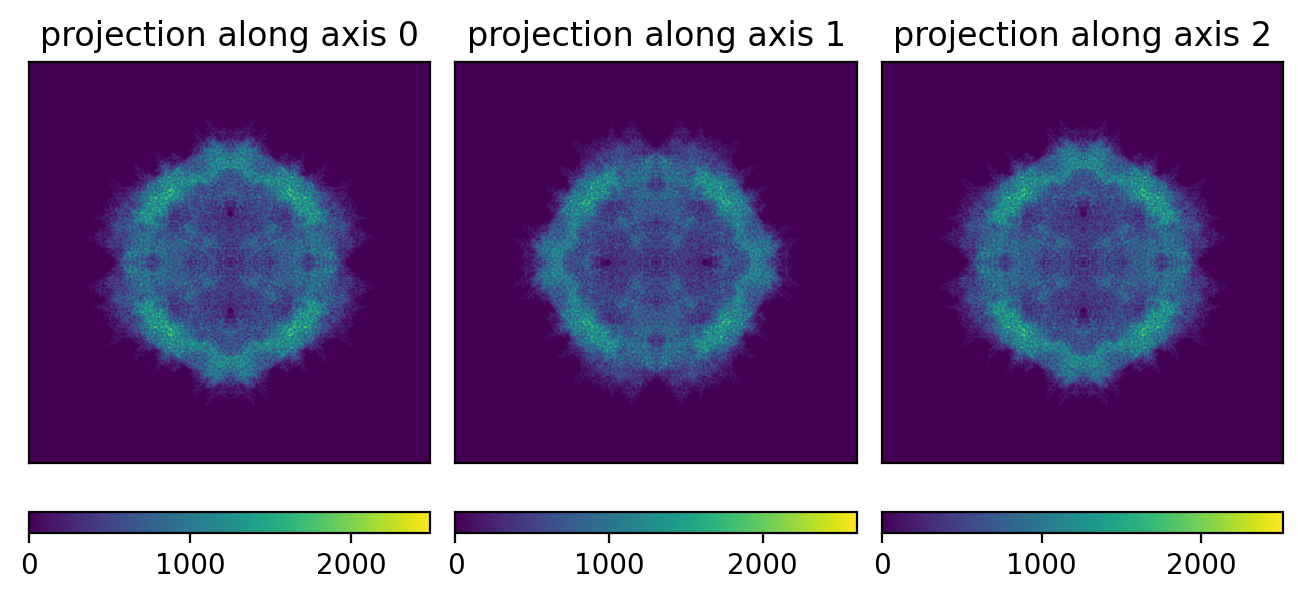

In [129]:
plot3d(vol_snapped_3d)

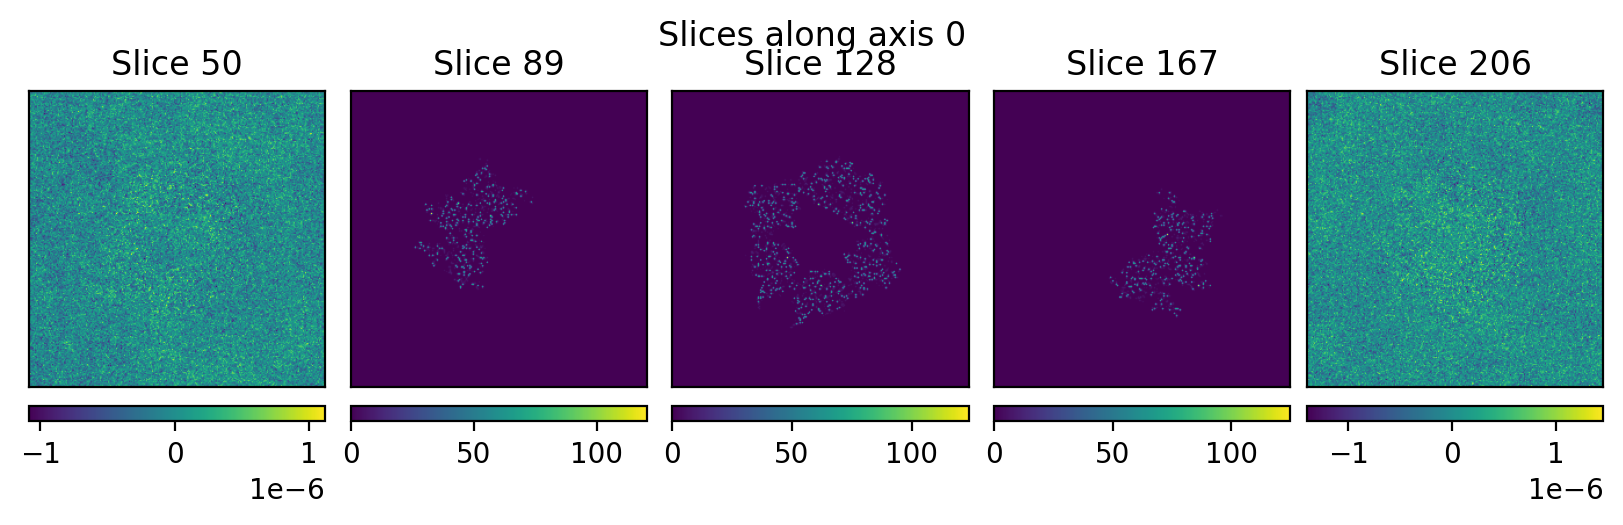

In [119]:
start_idx = 50
plot_slices(vol_snapped_3d, start_idx=start_idx, end_idx=n - start_idx)

## Compute volumetric potential from PDB (3D, Snap, High Res)

In [120]:
vol_snapped_3d_highres = potential.build_potential_volume_fftconvolve(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="snapped-3d",
    compute_high_res=True
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [01:02<00:00,  8.90s/it]


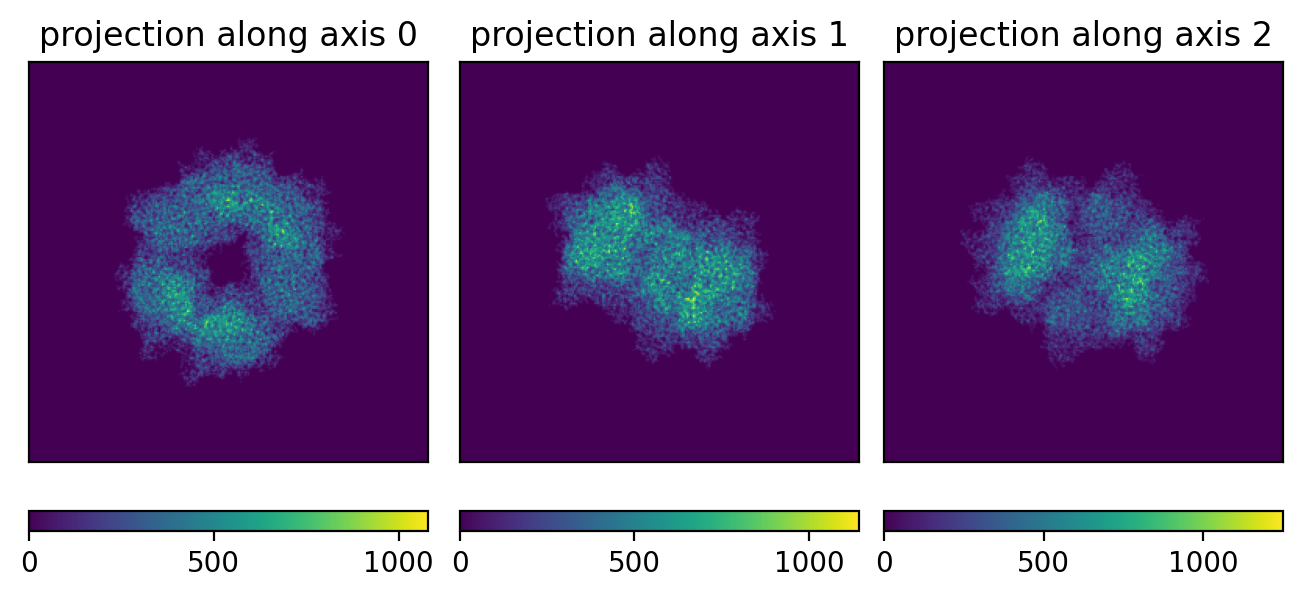

In [121]:
plot3d(vol_snapped_3d_highres)

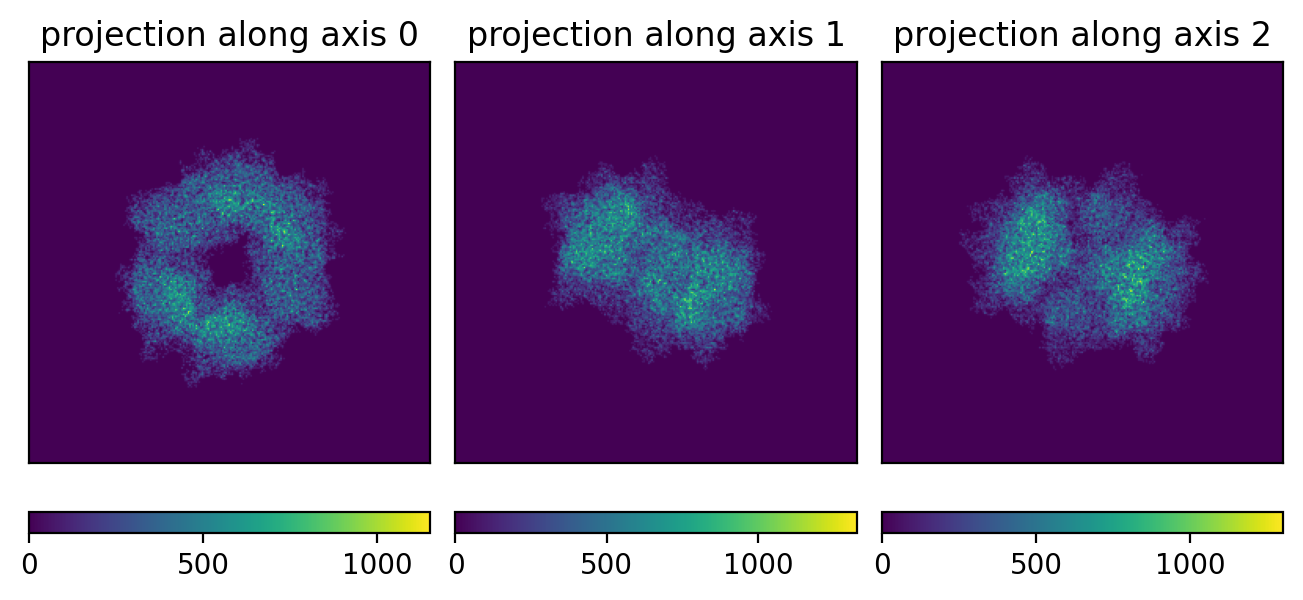

In [118]:
plot3d(vol_snapped_3d)

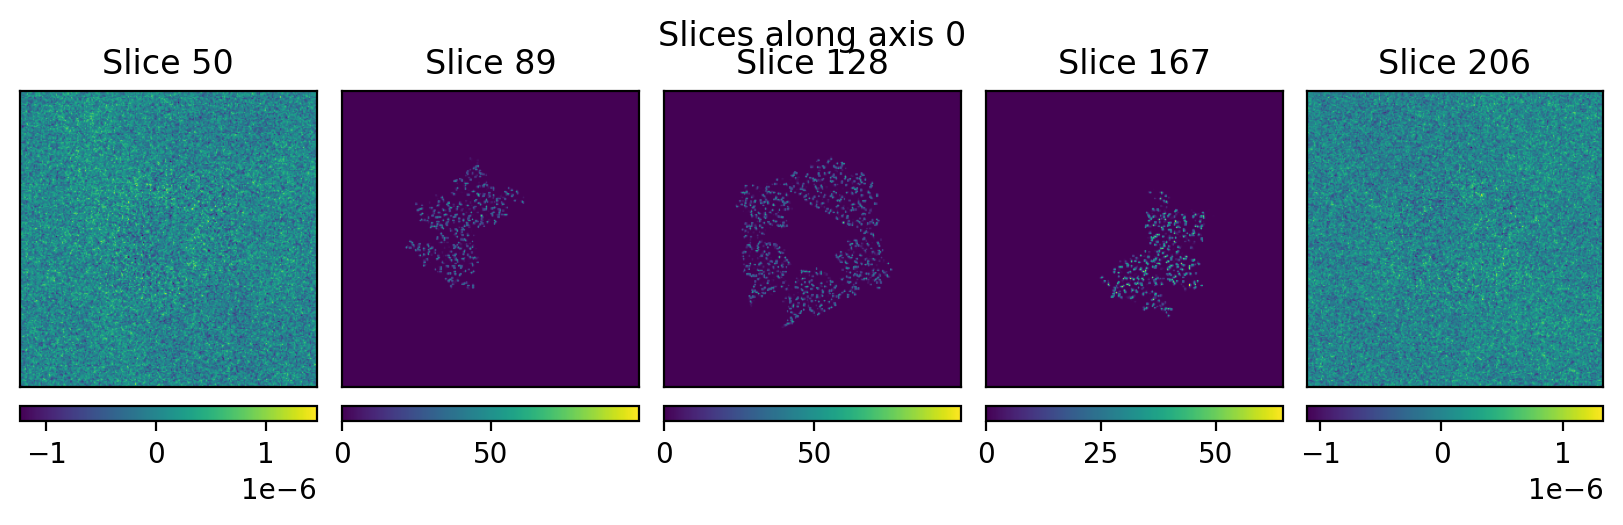

In [122]:
start_idx = 50
plot_slices(vol_snapped_3d_highres, start_idx=start_idx, end_idx=n - start_idx)

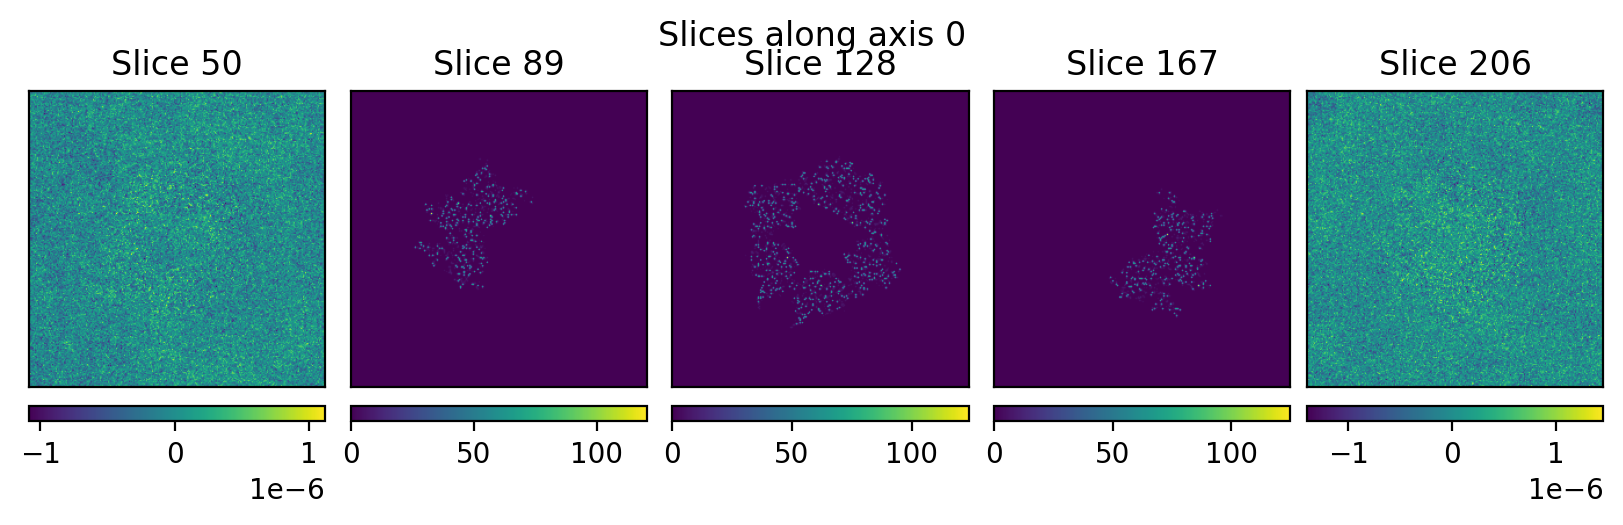

In [119]:
start_idx = 50
plot_slices(vol_snapped_3d, start_idx=start_idx, end_idx=n - start_idx)

## Compute volumetric potential from PDB (3D, Snap)

In [130]:
vol_snapped_3d = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="snapped-3d",
)

489900it [00:54, 8915.81it/s]


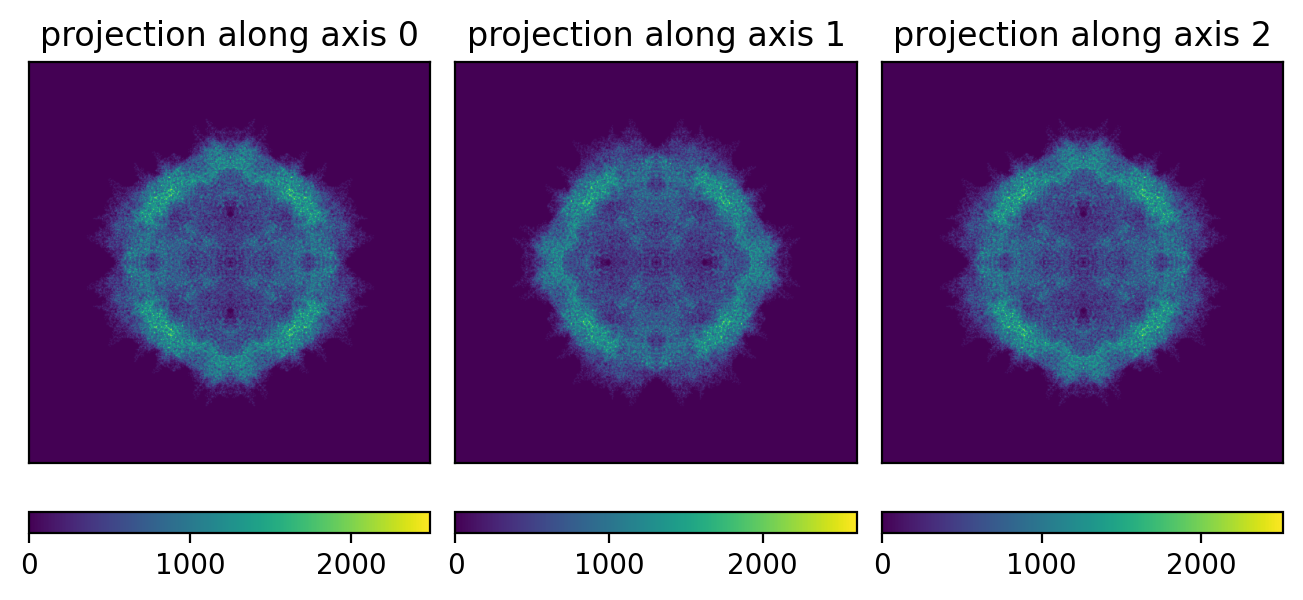

In [131]:
plot3d(vol_snapped_3d)

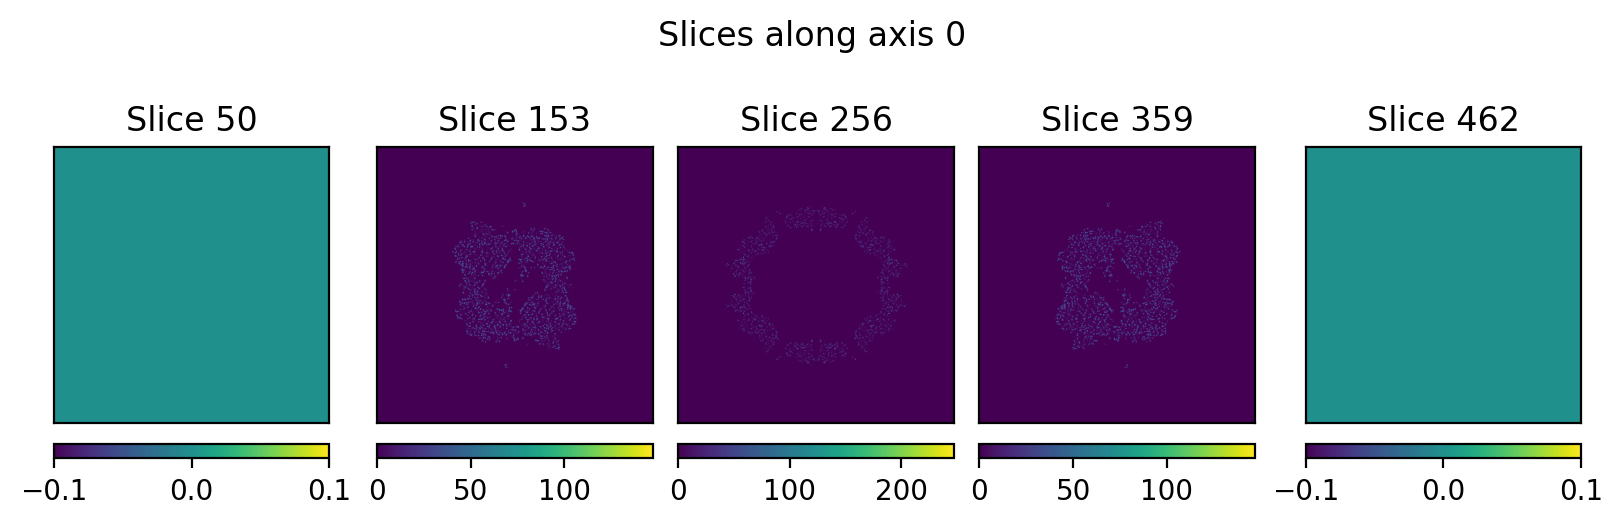

In [32]:
start_idx = 50
plot_slices(vol_snapped_3d, start_idx=start_idx, end_idx=n - start_idx)

## Compute volumetric potential from PDB (2D Projection, snap-in-z only)

In [291]:
vol_2d = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="2d",
)

37866it [02:02, 308.20it/s]


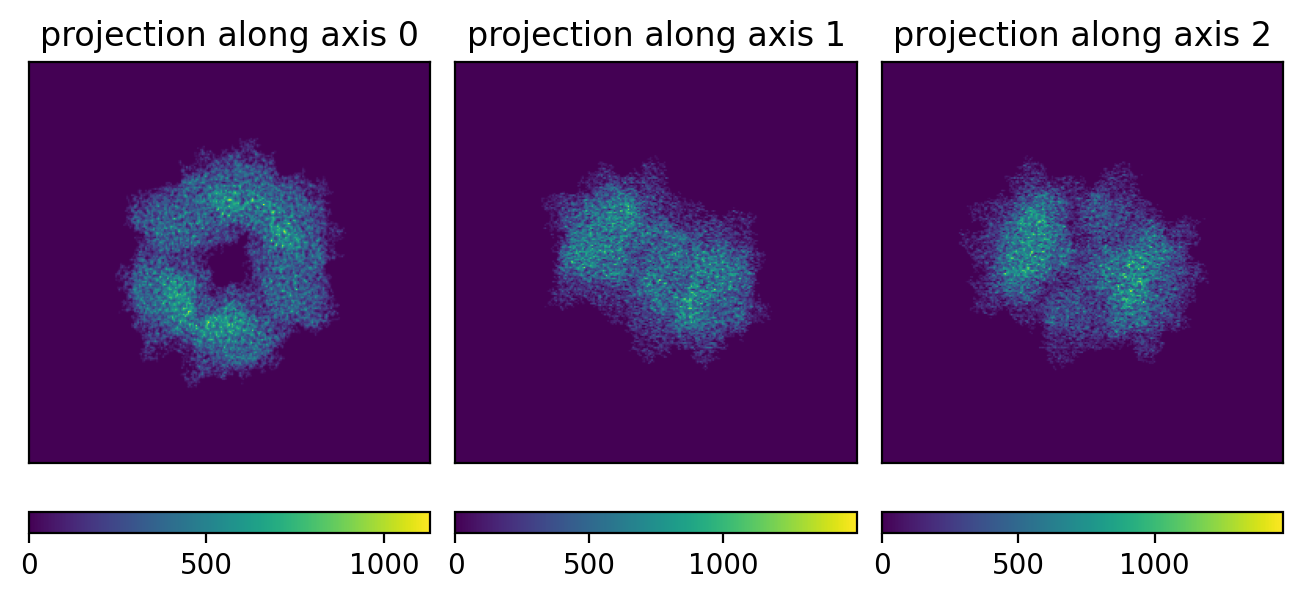

In [292]:
plot3d(vol_2d)

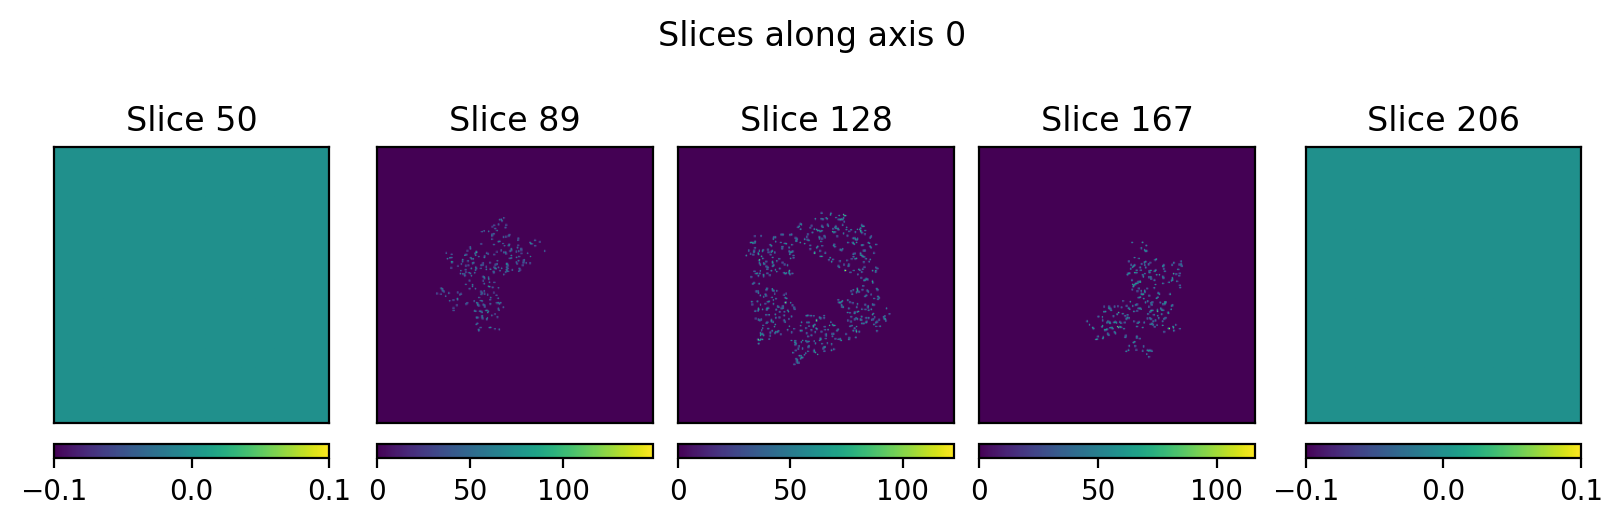

In [293]:
start_idx = 50
plot_slices(vol_2d, start_idx=start_idx, end_idx=n - start_idx)

## Compute volumetric potential from PDB (3D, no-snap)

In [33]:
vol_3d = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="3d",
)

489900it [30:17, 269.56it/s]


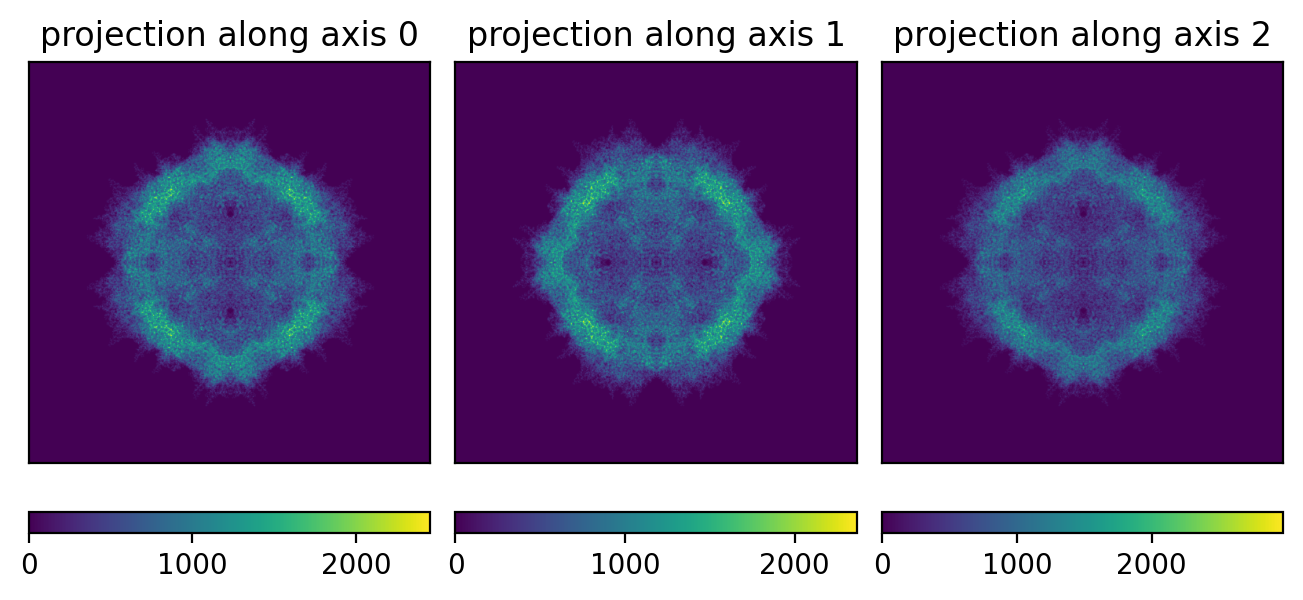

In [34]:
plot3d(vol_3d)

## Compare error between snap and no-snap

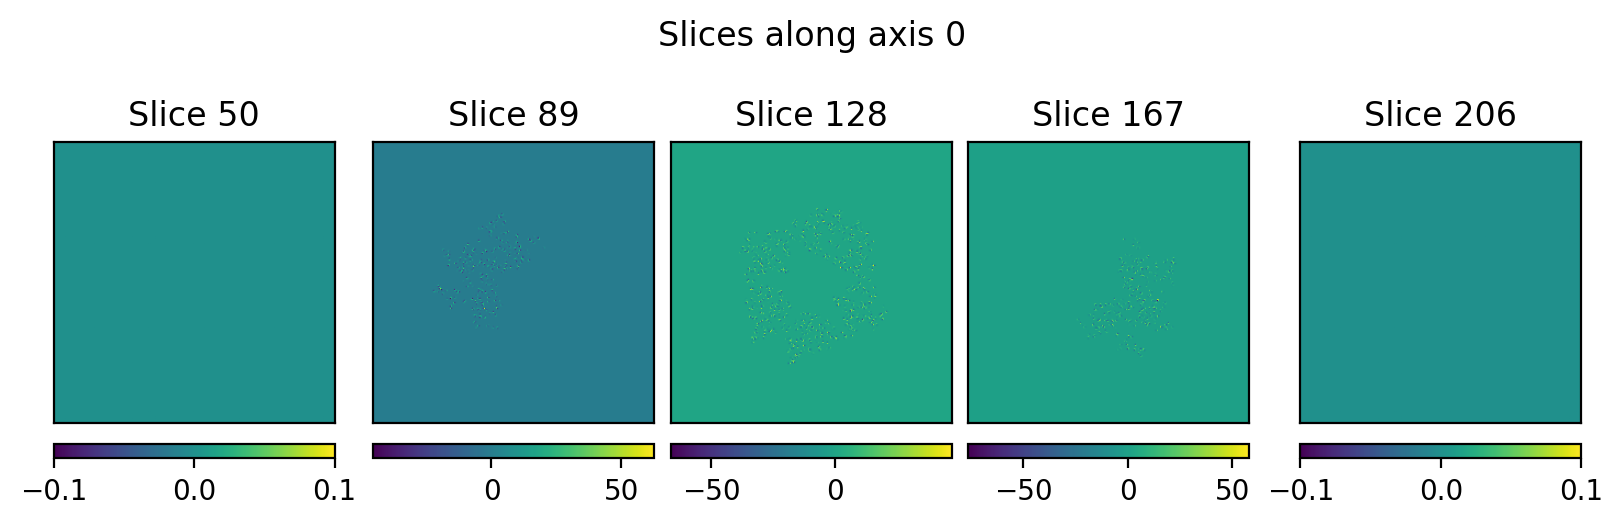

In [296]:
start_idx = 50
plot_slices(vol_2d - vol_snapped_2d, start_idx=start_idx, end_idx=n - start_idx)

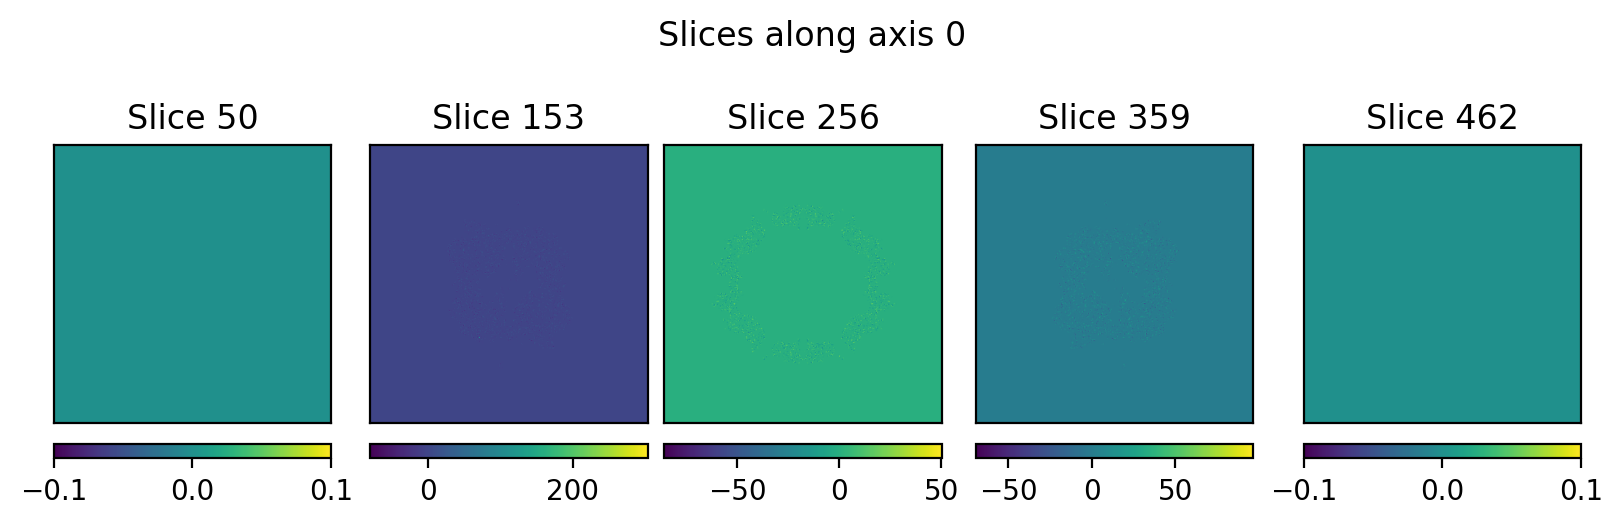

In [36]:
start_idx = 50
plot_slices(vol_3d - vol_snapped_3d, start_idx=start_idx, end_idx=n - start_idx)

## Solvate

In [134]:
ice_atomic_numbers, ice_coordinates = ice.volume_of_ice(
    n_xyz=(n, n, n), d_xyz=(dx, dx, dx)
)

2063603


In [137]:
ice_coordinates

tensor([[-140.6152,   80.9908, -144.2692],
        [-140.7131,   81.8786, -143.9251],
        [-139.6727,   80.8240, -144.2601],
        ...,
        [ -73.9190,  164.5187,  189.5661],
        [ -74.5249,  165.1882,  189.2486],
        [ -74.2402,  163.6974,  189.1942]])

In [138]:
dx = 0.788
n = 512
super_sampling_factor = 4
ice_vol_3d = potential.build_potential_volume_fftconvolve(
    torch.from_numpy(ice_atomic_numbers),
    ice_coordinates,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="snapped-3d",
    compute_high_res=False
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [03:15<00:00, 98.00s/it]


In [139]:
super_sampling_factor = 4
ice_vol_3d = potential.build_potential_volume(
    torch.from_numpy(ice_atomic_numbers),
    ice_coordinates,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=31,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="snapped-3d",
)

6190809it [11:34, 8909.65it/s]


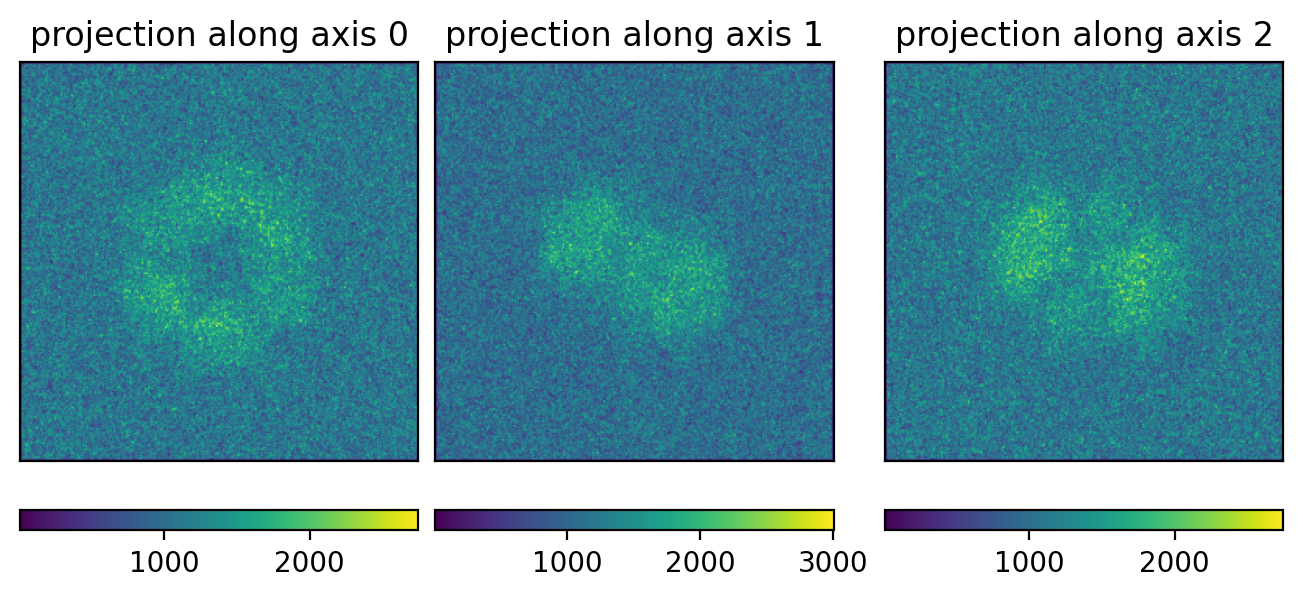

In [301]:
plot3d(ice_vol_3d + vol_3d)

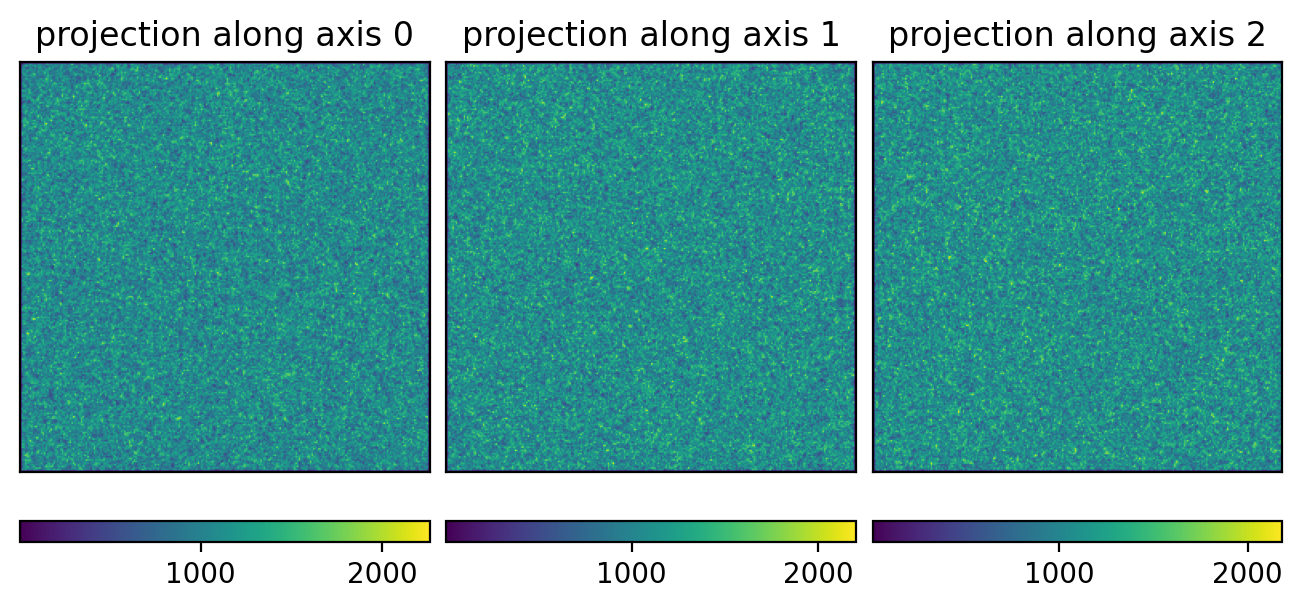

In [302]:
plot3d(ice_vol_3d)

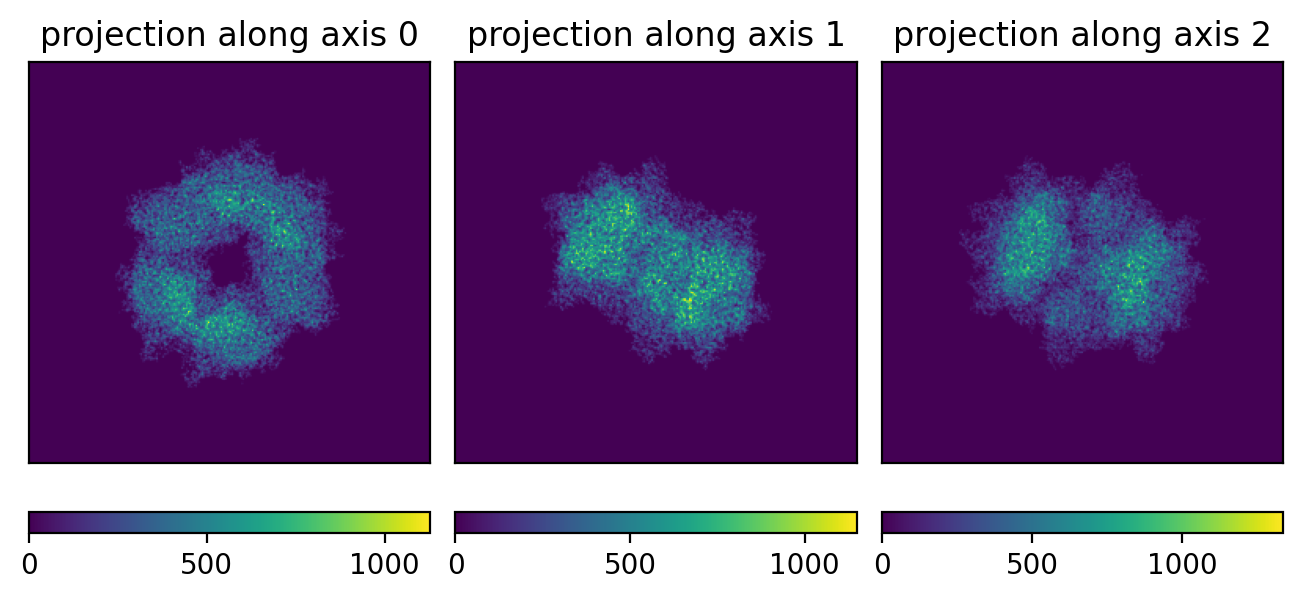

In [303]:
plot3d(vol_3d)